In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
test_list = [i for i in range(1, 11)]
left_list = [test_list[(i+1) % len(test_list)] for i in range(0, len(test_list))]

test_list, left_list

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [2, 3, 4, 5, 6, 7, 8, 9, 10, 1])

In [5]:
np.random.rand()

0.3094193805075238

In [112]:
def evolve(T, initial_state, epsilon):
    L_val = len(initial_state)
    current_state = initial_state

    saved_states = [current_state for _ in range(int(T+1))]

    for t in range(1, T+1):
        values = (np.random.random(L_val) < epsilon)
        left_neighbor_conv_values = [current_state[i]*current_state[(i+1) % L_val] for i in range(0, L_val)]
        current_state = values + ((1-values) * left_neighbor_conv_values)
        saved_states[t] = current_state
    
    return saved_states

def broad_random_evolve(T, initial_state, epsilon, a):
    L_val = len(initial_state)
    current_state = initial_state

    saved_states = [current_state for _ in range(int(T)+1)]

    n = (a/epsilon) - 1
    for t in range(1, T):
        ep = a*(np.random.rand()**n)
        values = (np.random.random(L_val) < ep)
        left_neighbor_conv_values = [current_state[i]*current_state[(i+1) % L_val] for i in range(0, L_val)]
        current_state = values + ((1-values) * left_neighbor_conv_values)
        saved_states[t] = current_state
    
    return saved_states

In [110]:
L = 500
time_pref = 1.0

num_runs = 1

epsilon = 0.253725

a = 0.5 # For broad randomness

# Get the random data

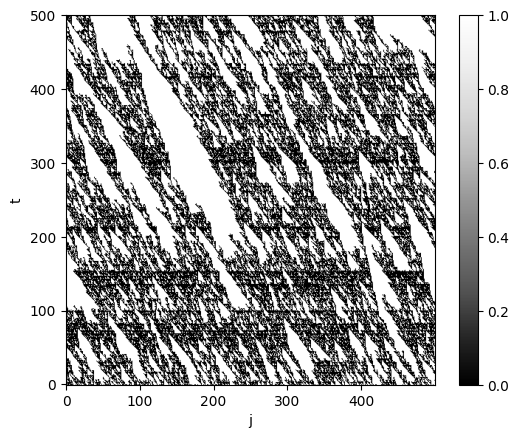

In [113]:
total_data = []

for run in range(num_runs):
    initial_state = (np.random.random(L) > 0.5) * 1
    total_data.append(broad_random_evolve(int(L*time_pref), initial_state, epsilon, a))

for run_data in total_data:
    plt.imshow(np.array(run_data), cmap="Grays_r")
    plt.colorbar()
    plt.xlabel('j')
    plt.ylabel('t')
    plt.gca().invert_yaxis()

# Get the original data

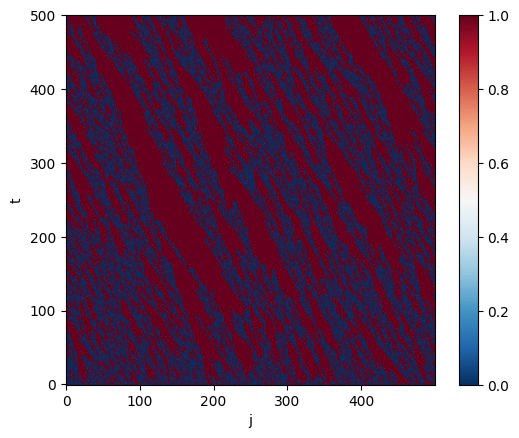

In [88]:
total_orig_data = []

epsilon = 0.29450

for run in range(num_runs):
    initial_state = (np.random.random(L) > 0.5) * 1
    total_orig_data.append(evolve(int(L*time_pref), initial_state, epsilon))

for run_data in total_orig_data:
    plt.imshow(np.array(run_data, np.int32), cmap="RdBu_r")
    plt.colorbar()
    plt.xlabel('j')
    plt.ylabel('t')
    plt.gca().invert_yaxis()